# Luogu CAPTCHA Recognition — Train & Export

Downloads the dataset from the Hugging Face Hub repo
[`langningchen/luogu-captcha-dataset`](https://huggingface.co/datasets/langningchen/luogu-captcha-dataset),
trains a small CNN to solve the 4-character captchas, and exports the trained
model to three formats:

- Keras `.h5` (for Python)
- TensorFlow.js layers model (for the browser)
- ONNX (for cross-platform / mobile runtimes)

Run the cells top to bottom. A GPU speeds up training a lot but is not required.

## 1. Install dependencies

In [ ]:
%pip install -U "huggingface-hub>=0.35" "onnx>=1.17,<2" "onnxruntime>=1.20,<2"
%pip install --no-deps "tensorflowjs==4.22.0" "tf2onnx>=1.16.1"

## 2. Imports and configuration

In [ ]:
import io
import json
import math
import os
import random
import shutil
import sys
import types
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from huggingface_hub import hf_hub_download
from tensorflow import keras
from tensorflow.keras import layers

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# ---------------- configuration ----------------
DATASET_REPO_ID = "langningchen/luogu-captcha-dataset"
WORK_DIR = Path("work")
DATA_DIR = WORK_DIR / "data"
OUTPUT_DIR = WORK_DIR / "export"
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ALPHABET = "abcdefghijklmnopqrstuvwxyz123456789"
IMAGE_HEIGHT = 35
IMAGE_WIDTH = 90
IMAGE_CHANNELS = 3
CAPTCHA_LENGTH = 4
SAMPLES_PER_TFRECORD = 5000

TOTAL_SAMPLES = 100_000     # how many samples to pull from the dataset
VALIDATION_SIZE = 10_000    # held out for validation (strict 9:1 split)
BATCH_SIZE = 512
EPOCHS = 30
SEED = 484858

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError:
            pass
    keras.mixed_precision.set_global_policy("mixed_float16")
    print(f"Using GPU (mixed precision): {gpus[0].name}")
else:
    print("No GPU detected -- training will be slower")


def build_ascii_lookup_table():
    mapping = np.zeros(256, dtype=np.int32)
    for idx, char in enumerate(MODEL_ALPHABET):
        mapping[ord(char.lower())] = idx
        mapping[ord(char.upper())] = idx
    return tf.constant(mapping, dtype=tf.int32)


ASCII_LOOKUP = build_ascii_lookup_table()

Using GPU (mixed precision): /physical_device:GPU:0


## 3. Download dataset shards from the Hugging Face Hub

In [ ]:
def download_shards(repo_id: str, total_samples: int, local_dir: Path) -> list[str]:
    needed_count = math.ceil(total_samples / SAMPLES_PER_TFRECORD)
    print(f"Need {total_samples:,} samples -> fetching {needed_count} shard file(s)...")
    paths = []
    for i in range(needed_count):
        fname = f"part_{i:05d}.tfrecord"
        local_path = local_dir / fname
        if not local_path.exists():
            downloaded = hf_hub_download(
                repo_id=repo_id,
                repo_type="dataset",
                filename=fname,
                local_dir=str(local_dir),
            )
            paths.append(downloaded)
        else:
            paths.append(str(local_path))
    return sorted(paths)


shard_paths = download_shards(DATASET_REPO_ID, TOTAL_SAMPLES, DATA_DIR)
print(f"Have {len(shard_paths)} shard file(s) locally.")

Need 100,000 samples -> fetching 20 shard file(s)...
Have 20 shard file(s) locally.


## 4. Build the `tf.data` pipeline (parse TFRecords, split train/val)

In [ ]:
def parse_tfrecord(example_proto):
    features = {
        "image": tf.io.FixedLenFeature([], tf.string),
        "label": tf.io.FixedLenFeature([CAPTCHA_LENGTH], tf.int64),
    }
    parsed = tf.io.parse_single_example(example_proto, features)
    image = tf.io.decode_jpeg(parsed["image"], channels=IMAGE_CHANNELS)
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.ensure_shape(image, [IMAGE_HEIGHT, IMAGE_WIDTH, IMAGE_CHANNELS])

    raw_labels = tf.cast(parsed["label"], tf.int32)
    labels = tf.gather(ASCII_LOOKUP, raw_labels)
    labels = tf.ensure_shape(labels, [CAPTCHA_LENGTH])
    return image, labels


def augment_image(image, labels):
    image = tf.image.random_brightness(image, max_delta=0.05)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, labels


full_ds = tf.data.TFRecordDataset(shard_paths, num_parallel_reads=tf.data.AUTOTUNE)
full_ds = full_ds.shuffle(buffer_size=25000, seed=SEED, reshuffle_each_iteration=False)

val_raw = full_ds.take(VALIDATION_SIZE)
train_raw = full_ds.skip(VALIDATION_SIZE)

train_dataset = (
    train_raw.shuffle(buffer_size=12000, seed=SEED, reshuffle_each_iteration=True)
    .map(parse_tfrecord, num_parallel_calls=tf.data.AUTOTUNE)
    .map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
    .repeat()
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    val_raw.map(parse_tfrecord, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE, drop_remainder=False)
    .prefetch(tf.data.AUTOTUNE)
)

train_steps = (TOTAL_SAMPLES - VALIDATION_SIZE) // BATCH_SIZE
val_steps = math.ceil(VALIDATION_SIZE / BATCH_SIZE)
print(f"train steps/epoch: {train_steps} | val steps/epoch: {val_steps}")

train steps/epoch: 175 | val steps/epoch: 20


### 4b. (Optional) Quick label-overlap sanity check

If validation accuracy climbs suspiciously fast, it is worth checking whether
the same captcha *text* (or, more thoroughly, near-duplicate images) shows up
in both train and val. This cell only checks label text overlap cheaply as a
first signal — it is not a substitute for a full pixel/perceptual-hash
duplicate scan across the whole dataset, which is better done as a separate
offline script.

In [ ]:
def peek_labels(dataset_raw, limit):
    features = {
        "image": tf.io.FixedLenFeature([], tf.string),
        "label": tf.io.FixedLenFeature([CAPTCHA_LENGTH], tf.int64),
    }
    texts = []
    for raw in dataset_raw.take(limit):
        parsed = tf.io.parse_single_example(raw, features)
        texts.append("".join(chr(c) for c in parsed["label"].numpy()))
    return texts


val_labels = peek_labels(val_raw, VALIDATION_SIZE)
train_labels_sample = peek_labels(train_raw, 20000)  # sample only, for speed

val_unique = len(set(val_labels))
overlap = len(set(train_labels_sample) & set(val_labels))
print(f"val set: {len(val_labels)} samples, {val_unique} unique label texts")
print(
    f"label overlap between a 20k train sample and the full val set: {overlap} "
    f"({overlap / max(1, val_unique):.1%} of val's unique labels)"
)

val set: 10000 samples, 9996 unique label texts
label overlap between a 20k train sample and the full val set: 19 (0.2% of val's unique labels)


## 5. Model architecture

In [ ]:
def conv_bn_relu(x, filters, kernel_size=3, strides=1):
    x = layers.Conv2D(filters, kernel_size, strides=strides, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    return layers.ReLU()(x)


def se_block(x, ratio=16):
    channels = x.shape[-1]
    se = layers.GlobalAveragePooling2D(keepdims=True)(x)
    se = layers.Dense(channels // ratio, activation="relu")(se)
    se = layers.Dense(channels, activation="sigmoid")(se)
    return layers.multiply([x, se])


def res_block_se(x, filters):
    shortcut = x
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    y = conv_bn_relu(x, filters, 3)
    y = layers.Conv2D(filters, 3, padding="same", use_bias=False)(y)
    y = layers.BatchNormalization()(y)
    y = se_block(y)

    out = layers.add([shortcut, y])
    return layers.ReLU()(out)


def build_model():
    inputs = keras.Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, IMAGE_CHANNELS), name="captcha")

    x = conv_bn_relu(inputs, 32, 3)
    x = res_block_se(x, 32)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)

    x = res_block_se(x, 64)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)

    x = res_block_se(x, 128)
    x = layers.MaxPooling2D(pool_size=(2, 1))(x)

    x = res_block_se(x, 256)
    x = layers.MaxPooling2D(pool_size=(4, 1))(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Reshape((22, 256))(x)

    seq = layers.Conv1D(256, kernel_size=5, padding="same", activation="relu")(x)
    seq = layers.BatchNormalization()(seq)

    avg_pool = layers.AveragePooling1D(pool_size=5, strides=5, padding="valid")(seq)
    max_pool = layers.MaxPooling1D(pool_size=5, strides=5, padding="valid")(seq)
    slot_feat = layers.add([avg_pool, max_pool])

    slot_feat = layers.Dropout(0.3)(slot_feat)
    slot_feat = layers.Dense(192, activation="relu")(slot_feat)
    slot_feat = layers.BatchNormalization()(slot_feat)
    slot_feat = layers.Dropout(0.2)(slot_feat)

    num_classes = len(MODEL_ALPHABET)
    outputs = layers.Dense(num_classes, dtype="float32", name="characters")(slot_feat)

    return keras.Model(inputs, outputs, name="luogu_captcha")


@keras.utils.register_keras_serializable(package="luoguCaptcha")
def captcha_accuracy(labels, logits):
    predicted = tf.argmax(logits, axis=-1, output_type=tf.int32)
    labels = tf.cast(labels, tf.int32)
    exact_matches = tf.reduce_all(tf.equal(labels, predicted), axis=-1)
    return tf.cast(exact_matches, tf.float32)


model = build_model()
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=2e-3, weight_decay=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="char_accuracy"), captcha_accuracy],
)
model.summary()

Model: "luogu_captcha"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ captcha             │ (None, 35, 90, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 35, 90,    │        864 │ captcha[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 90,    │        128 │ conv2d_30[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_25 (ReLU)     │ (None, 35, 90,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 35, 90,    │      9,216 │ re_lu_25[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 90,    │        128 │ conv2d_31[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_26 (ReLU)     │ (None, 35, 90,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 35, 90,    │      9,216 │ re_lu_26[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 90,    │        128 │ conv2d_32[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1, 1, 32)  │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 1, 1, 2)   │         66 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1, 1, 32)  │         96 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 35, 90,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 35, 90,    │          0 │ re_lu_25[0][0],   │
│                     │ 32)               │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_27 (ReLU)     │ (None, 35, 90,    │          0 │ add_8[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 17, 45,    │          0 │ re_lu_27[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 17, 45,    │     18,432 │ max_pooling2d_10… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,626,497 (6.20 MB)

 Trainable params: 1,622,721 (6.19 MB)

 Non-trainable params: 3,776 (14.75 KB)

## 6. Train

In [ ]:
checkpoint_path = OUTPUT_DIR / "best.weights.h5"

EPOCHS_OPTIMIZED = 40

lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=2e-3,
    decay_steps=train_steps * EPOCHS_OPTIMIZED,
    alpha=0.01,
)

model.optimizer.learning_rate = lr_schedule

callbacks = [
    keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_captcha_accuracy",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_captcha_accuracy",
        mode="max",
        patience=10,
        restore_best_weights=True,
    ),
    keras.callbacks.TerminateOnNaN(),
]

print("Starting training with Cosine Decay and SE-Slot Architecture...")
history = model.fit(
    train_dataset,
    steps_per_epoch=train_steps,
    validation_data=val_dataset,
    validation_steps=val_steps,
    epochs=EPOCHS_OPTIMIZED,
    callbacks=callbacks,
    verbose=1,
)

keras_h5_path = OUTPUT_DIR / "luogu-captcha-mobile.h5"
model.save(keras_h5_path, include_optimizer=False)
print(f"Training complete. Best model saved to {keras_h5_path}")

Starting training with Cosine Decay and SE-Slot Architecture...
Epoch 1/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 64s 189ms/step - captcha_accuracy: 0.0463 - char_accuracy: 0.2762 - loss: 2.6270 - val_captcha_accuracy: 0.0000e+00 - val_char_accuracy: 0.0487 - val_loss: 4.8378
Epoch 2/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 29s 167ms/step - captcha_accuracy: 0.4537 - char_accuracy: 0.7950 - loss: 0.6753 - val_captcha_accuracy: 0.2757 - val_char_accuracy: 0.6984 - val_loss: 1.0524
Epoch 3/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 27s 155ms/step - captcha_accuracy: 0.6577 - char_accuracy: 0.8903 - loss: 0.3570 - val_captcha_accuracy: 0.6404 - val_char_accuracy: 0.8850 - val_loss: 0.3708
Epoch 4/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 39s 222ms/step - captcha_accuracy: 0.7390 - char_accuracy: 0.9206 - loss: 0.2564 - val_captcha_accuracy: 0.7605 - val_char_accuracy: 0.9285 - val_loss: 0.2301
Epoch 5/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 41s 235ms/step - captcha_accuracy: 0.7830 - char_accuracy: 0.9363 - loss: 0.2019 - val_captcha_a

Training complete. Best model saved to work/export/luogu-captcha-mobile.h5


## 7. Inspect training curves and a few predictions

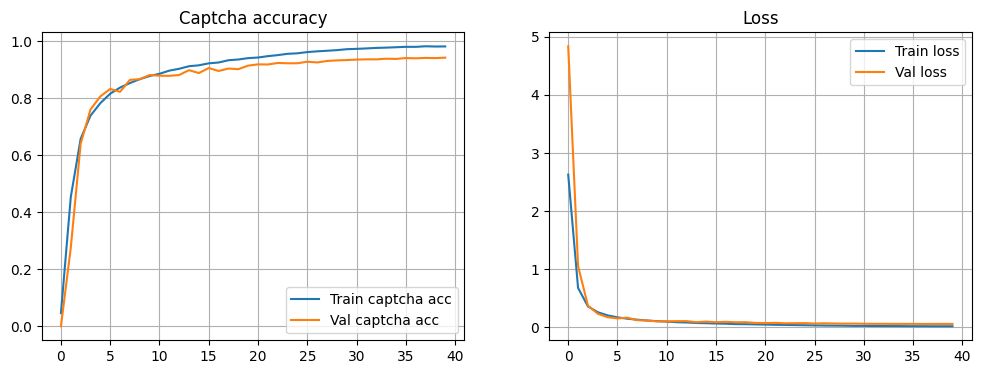

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


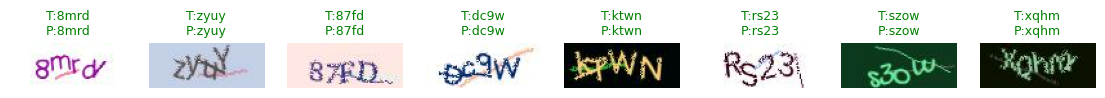

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["captcha_accuracy"], label="Train captcha acc")
plt.plot(history.history["val_captcha_accuracy"], label="Val captcha acc")
plt.title("Captcha accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Val loss")
plt.title("Loss")
plt.legend()
plt.grid(True)
plt.show()

for imgs, lbls in val_dataset.take(1):
    preds = model.predict(imgs[:8])
    pred_indices = np.argmax(preds, axis=-1)

    plt.figure(figsize=(14, 2.5))
    for i in range(8):
        plt.subplot(1, 8, i + 1)
        plt.imshow(imgs[i].numpy())
        true_text = "".join(MODEL_ALPHABET[idx] for idx in lbls[i].numpy())
        pred_text = "".join(MODEL_ALPHABET[idx] for idx in pred_indices[i])
        color = "green" if true_text == pred_text else "red"
        plt.title(f"T:{true_text}\nP:{pred_text}", color=color, fontsize=9)
        plt.axis("off")
    plt.show()
    break

## 8. Export — Keras / TensorFlow.js / ONNX

### 8a. Work around the `tensorflow_decision_forests` import crash

`tensorflowjs`'s converter module unconditionally imports
`tensorflow_decision_forests`, even though we never touch a TFDF model here.
If that package is missing or incompatible with the current TF/Python
version, importing `tensorflowjs` crashes outright. The cell below installs a
harmless stub so the import chain succeeds; TFDF-specific code paths inside
`tensorflowjs` are never reached with a plain Keras `Functional` model.

In [ ]:
def install_tfdf_stub_if_needed():
    if "tensorflow_decision_forests" in sys.modules:
        return
    try:
        import tensorflow_decision_forests  # noqa: F401
        return
    except Exception as e:
        print(f"tensorflow_decision_forests unavailable ({e!r}); installing a stub.")

    keras_stub = types.ModuleType("tensorflow_decision_forests.keras")

    class _CoreModelStub:
        """Placeholder so isinstance() checks inside tensorflowjs do not crash."""

    keras_stub.CoreModel = _CoreModelStub
    tfdf_stub = types.ModuleType("tensorflow_decision_forests")
    tfdf_stub.keras = keras_stub
    sys.modules["tensorflow_decision_forests"] = tfdf_stub
    sys.modules["tensorflow_decision_forests.keras"] = keras_stub


install_tfdf_stub_if_needed()

import tensorflowjs as tfjs
from tensorflowjs.converters import converter as tfjs_converter_cli

print("tensorflowjs version:", tfjs.__version__)

tensorflowjs version: 4.22.0


### 8b. Convert to TensorFlow.js

In [ ]:
tfjs_dir = OUTPUT_DIR / "tfjs"
if tfjs_dir.exists():
    shutil.rmtree(tfjs_dir)
tfjs_dir.mkdir(parents=True)

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # conversion runs fine on CPU only

conversion_args = [
    "--input_format=keras",
    "--output_format=tfjs_layers_model",
    "--quantize_uint8=*",
    str(keras_h5_path),
    str(tfjs_dir),
]

print("Converting to TensorFlow.js (uint8 quantized)...")
try:
    tfjs_converter_cli.convert(conversion_args)
except Exception as e:
    print(f"Quantized conversion failed ({e!r}); retrying without quantization...")
    conversion_args_fallback = [
        "--input_format=keras",
        "--output_format=tfjs_layers_model",
        str(keras_h5_path),
        str(tfjs_dir),
    ]
    tfjs_converter_cli.convert(conversion_args_fallback)

print("Conversion finished.")

Converting to TensorFlow.js (uint8 quantized)...
failed to lookup keras version from the file,
    this is likely a weight only file
Conversion finished.


### 8c. Patch `model.json` topology for Keras 3 -> tfjs 4.22 compatibility

Keras 3's saved config format differs enough from what `tensorflowjs` 4.22's
loader expects (`Functional` vs `Model` class name, `batch_shape` vs
`batchInputShape`, and a different `inbound_nodes` encoding) that the raw
converter output can fail to load in the browser. This patches
`modelTopology` in place into the shape the tfjs loader expects.

In [ ]:
def fix_tfjs_model_json(tfjs_output_dir: Path) -> None:
    model_json_path = tfjs_output_dir / "model.json"
    if not model_json_path.exists():
        print("model.json not found -- skipping topology fix")
        return

    model_json = json.loads(model_json_path.read_text(encoding="utf-8"))
    model_config = model_json.get("modelTopology", {}).get("model_config", {})
    if not isinstance(model_config, dict):
        return

    if model_config.get("class_name") in ("Functional", "Model"):
        model_config["class_name"] = "Model"

    config = model_config.get("config", {})
    for key in ("input_layers", "output_layers"):
        value = config.get(key)
        if value and not isinstance(value[0], list):
            config[key] = [value]

    for layer in config.get("layers", []):
        layer_cfg = layer.get("config", {})
        if layer.get("class_name") == "InputLayer" and "batch_shape" in layer_cfg:
            layer_cfg["batchInputShape"] = layer_cfg.pop("batch_shape")
            layer_cfg.pop("optional", None)

        normalized_nodes = []
        for node in layer.get("inbound_nodes", []):
            if isinstance(node, list):
                normalized_nodes.append(node)
                continue
            if isinstance(node, dict):
                connections = []
                for arg in node.get("args", []):
                    history = (
                        arg.get("config", {}).get("keras_history")
                        if isinstance(arg, dict)
                        else None
                    )
                    if history and len(history) == 3:
                        connections.append([*history, {}])
                if connections:
                    normalized_nodes.append(connections)
        if normalized_nodes:
            layer["inbound_nodes"] = normalized_nodes

    model_json_path.write_text(
        json.dumps(model_json, ensure_ascii=True, separators=(",", ":")),
        encoding="utf-8",
    )
    print("model.json topology patched for tfjs compatibility.")


fix_tfjs_model_json(tfjs_dir)

model.json topology patched for tfjs compatibility.


### 8d. Export ONNX

Sanity check after this cell runs: load `model.json` with `tf.loadLayersModel()`
in an actual browser page and compare its output to the Python-side prediction
on the same image. The JSON patch above is heuristic, so a conversion that
"succeeds" is not the same as a conversion that produces correct predictions.

In [ ]:
onnx_dir = OUTPUT_DIR / "onnx"
if onnx_dir.exists():
    shutil.rmtree(onnx_dir)
onnx_dir.mkdir(parents=True)
onnx_path = onnx_dir / "luogu-captcha-fp32.onnx"

input_signature = [
    tf.TensorSpec(
        shape=(None, IMAGE_HEIGHT, IMAGE_WIDTH, IMAGE_CHANNELS),
        dtype=tf.float32,
        name="captcha",
    )
]
model.export(
    onnx_path,
    format="onnx",
    input_signature=input_signature,
    opset_version=18,
    verbose=False,
)
print(f"ONNX model exported to {onnx_path}")

ValueError: Unable to save the object ListWrapper([<Variable path=adamw/iteration, shape=(), dtype=int64, value=7000>, <Variable path=loss_scale_optimizer/adamw/conv2d_30_kernel_momentum, shape=(3, 3, 3, 32), dtype=float32, value=[[[[-4.51370201e-04 -1.62822602e-03 -1.53839856e-03  2.71833618e-04
    -1.28347492e-05  5.25945332e-04  6.11531839e-04 -3.63261998e-03
     1.08414322e-04  3.14766658e-06 -1.30211050e-03  1.31200312e-03
    -1.07330408e-04 -2.07136894e-04 -5.32464415e-04 -7.10113527e-05
    -8.52464058e-04 -2.93177832e-03 -2.78720923e-04  6.60121732e-04
    -7.94543303e-06 -5.79858664e-04  1.92489370e-05 -6.79112345e-05
    -3.21871310e-04  8.94412369e-05 -3.14630161e-04 -7.69766630e-05
    -1.65331236e-04 -1.61939114e-03 -1.87085505e-04 -4.99984890e-04]
   [-9.18384001e-04 -1.43584807e-03 -1.89652876e-03  9.08989896e-05
     3.97186486e-05  1.16661831e-04  3.21096537e-04 -3.06758075e-03
     5.97952749e-05  7.09072447e-06 -2.28724093e-03  4.43155208e-04
    -2.41490139e-04 -

## 9. Write metadata, package everything, and download

In [ ]:
best_val_acc = float(max(history.history.get("val_captcha_accuracy", [0.0])))
metadata = {
    "alphabet": MODEL_ALPHABET,
    "captcha_length": CAPTCHA_LENGTH,
    "image_height": IMAGE_HEIGHT,
    "image_width": IMAGE_WIDTH,
    "parameter_count": model.count_params(),
    "best_val_accuracy": best_val_acc,
}
(OUTPUT_DIR / "metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print(f"Best validation captcha accuracy: {best_val_acc:.2%}")
print("\nExport directory contents:")
for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(OUTPUT_DIR)}  ({p.stat().st_size / 1024:.1f} KB)")

archive_path = shutil.make_archive(str(WORK_DIR / "luogu-captcha-models"), "zip", OUTPUT_DIR)
print(f"\nPackaged everything into: {archive_path}")

try:
    from google.colab import files as colab_files
    colab_files.download(archive_path)
except ImportError:
    print(
        "Not running in Colab -- find the zip file at the path printed above "
        "and copy it off the machine yourself (e.g. scp/rsync)."
    )

## 10. Upload to Hugging Face Model Hub

In [ ]:
from huggingface_hub import HfApi, create_repo, login
import os
from google.colab import userdata

HF_MODEL_REPO_ID = "langningchen/luogu-captcha-model"

hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)
api = HfApi()

try:
    create_repo(repo_id=HF_MODEL_REPO_ID, repo_type="model", exist_ok=True)
    print(f"Repository {HF_MODEL_REPO_ID} verified/created.")
except Exception as e:
    print(f"Note on create_repo: {e}")

readme_content = f"""---
language:
- en
license: mit
tags:
- captcha
- ocr
- tensorflow
- keras
- onnx
- tensorflowjs
datasets:
- langningchen/luogu-captcha-dataset
metrics:
- accuracy
---

# Luogu CAPTCHA Recognition Model

Lightweight CNN model trained on [`langningchen/luogu-captcha-dataset`](https://huggingface.co/datasets/langningchen/luogu-captcha-dataset) to recognize 4-character Luogu CAPTCHAs.

## Model Performance
- **Validation Captcha Accuracy (Whole Sequence)**: {best_val_acc:.2%}
- **Input Dimensions**: {IMAGE_HEIGHT}x{IMAGE_WIDTH}x{IMAGE_CHANNELS} (Normalized to [0, 1])
- **Alphabet**: `{MODEL_ALPHABET}` (Length: {len(MODEL_ALPHABET)})

## Export Formats
- `luogu-captcha-mobile.h5`: Keras / TensorFlow HDF5 model
- `onnx/luogu-captcha-fp32.onnx`: ONNX model (Opset 18) for native/cross-platform runtimes
- `tfjs/`: TensorFlow.js Layers format with quantized weights for in-browser inference
"""

readme_path = OUTPUT_DIR / "README.md"
readme_path.write_text(readme_content, encoding="utf-8")

print(f"Uploading exported models to https://huggingface.co/{HF_MODEL_REPO_ID} ...")
api.upload_folder(
    folder_path=str(OUTPUT_DIR),
    repo_id=HF_MODEL_REPO_ID,
    repo_type="model",
    commit_message=f"Upload trained models (Val Acc: {best_val_acc:.2%})",
)

print(f"Successfully uploaded! Check your model at: https://huggingface.co/{HF_MODEL_REPO_ID}")

## 11. Generate predict.user.js

In [ ]:
import base64
import copy
import json
import re
from pathlib import Path
from huggingface_hub import hf_hub_download
from google.colab import files

REPO_ID = "langningchen/luogu-captcha-model"
REVISION = "da1d19cd2ec2dcb883edf06e81f25b0d4dc00983"
BEGIN_MARKER = "    // BEGIN EMBEDDED MODEL"
END_MARKER = "    // END EMBEDDED MODEL"

# 1. 你的原生 Userscript 模板
USERSCRIPT_TEMPLATE = """// ==UserScript==
// @name        Luogu Captcha
// @namespace   https://github.com/langningchen
// @version     1.1.1
// @description Fill Luogu captchas locally with a cached TensorFlow.js model
// @author      langningchen
// @match       *://www.luogu.com.cn/*
// @icon        https://www.luogu.com.cn/favicon.ico
// @homepageURL https://github.com/langningchen/luoguCaptcha
// @supportURL  https://github.com/langningchen/luoguCaptcha/issues
// @grant       none
// @require     https://cdn.jsdelivr.net/npm/@tensorflow/tfjs@4.22.0/dist/tf.min.js
// @updateURL   https://github.com/langningchen/luoguCaptcha/raw/refs/heads/main/predict.user.js
// @downloadURL https://github.com/langningchen/luoguCaptcha/raw/refs/heads/main/predict.user.js
// @run-at      document-start
// ==/UserScript==

(() => {
    'use strict';

    // BEGIN EMBEDDED MODEL
    // END EMBEDDED MODEL
    const ALPHABET = 'abcdefghijklmnopqrstuvwxyz123456789';
    const IMAGE_HEIGHT = 35;
    const IMAGE_WIDTH = 90;
    const CAPTCHA_LENGTH = 4;
    const CAPTCHA_IMAGE_SELECTOR = [
        'img[src*="captcha" i]',
        'img[src*="/captcha" i]',
        'img[alt*="验证码"]',
        'img[class*="captcha" i]',
        'img[data-testid*="captcha" i]'
    ].join(',');
    const INPUT_SELECTOR = [
        'input[placeholder*="验证码"]',
        'input[aria-label*="验证码"]',
        'input[placeholder*="captcha" i]',
        'input[aria-label*="captcha" i]',
        'input[name*="captcha" i]',
        'input[id*="captcha" i]',
        'input[data-testid*="captcha" i]'
    ].join(',');

    let modelPromise;
    let scanScheduled = false;
    const scanRoots = new Set();
    const processedSources = new WeakMap();
    const pendingImages = new WeakSet();

    const decodeBase64 = (encoded) => {
        const binary = atob(encoded);
        const bytes = new Uint8Array(binary.length);
        for (let index = 0; index < binary.length; index += 1) {
            bytes[index] = binary.charCodeAt(index);
        }
        return bytes.buffer;
    };

    const disposePrediction = (prediction) => {
        if (Array.isArray(prediction)) {
            prediction.forEach((tensor) => tensor.dispose());
        } else {
            prediction.dispose();
        }
    };

    const loadModel = () => {
        if (!modelPromise) {
            modelPromise = (async () => {
                await tf.ready();
                const handler = tf.io.fromMemory({
                    modelTopology: MODEL_TOPOLOGY,
                    weightSpecs: MODEL_WEIGHT_SPECS,
                    weightData: decodeBase64(MODEL_WEIGHT_DATA_BASE64)
                });
                const model = await tf.loadLayersModel(handler);
                const warmupInput = tf.zeros([1, IMAGE_HEIGHT, IMAGE_WIDTH, 3]);
                const warmupPrediction = model.predict(warmupInput);
                const warmupOutput = Array.isArray(warmupPrediction)
                    ? warmupPrediction[0]
                    : warmupPrediction;
                await warmupOutput.data();
                warmupInput.dispose();
                disposePrediction(warmupPrediction);
                return model;
            })().catch((error) => {
                modelPromise = undefined;
                throw error;
            });
        }
        return modelPromise;
    };

    const imageToTensor = (imageElement) => tf.tidy(() => {
        const canvas = document.createElement('canvas');
        canvas.width = imageElement.naturalWidth || imageElement.width;
        canvas.height = imageElement.naturalHeight || imageElement.height;
        if (!canvas.width || !canvas.height) {
            throw new Error('Captcha image has no dimensions');
        }
        const context = canvas.getContext('2d', { willReadFrequently: true });
        if (!context) throw new Error('Unable to create a canvas context');
        context.drawImage(imageElement, 0, 0, canvas.width, canvas.height);

        return tf.browser
            .fromPixels(canvas, 3)
            .resizeBilinear([IMAGE_HEIGHT, IMAGE_WIDTH], false)
            .toFloat()
            .div(255)
            .expandDims(0);
    });

    const predict = async (imageElement) => {
        const model = await loadModel();
        const input = imageToTensor(imageElement);
        let prediction;
        let classIds;
        try {
            prediction = model.predict(input);
            const output = Array.isArray(prediction) ? prediction[0] : prediction;
            classIds = output.argMax(-1);
            const indices = await classIds.data();
            if (indices.length !== CAPTCHA_LENGTH) {
                throw new Error(`Unexpected model output length: ${indices.length}`);
            }
            return Array.from(indices, (index) => ALPHABET[index]).join('');
        } finally {
            input.dispose();
            classIds?.dispose();
            if (prediction) disposePrediction(prediction);
        }
    };

    const isVisible = (element) => (
        element.isConnected && element.getClientRects().length > 0
    );

    const findCaptchaInput = (imageElement) => {
        const scopes = [
            imageElement.closest('form'),
            imageElement.closest('[role="dialog"]'),
            imageElement.parentElement,
            document
        ].filter(Boolean);
        const seenScopes = new Set();
        for (const scope of scopes) {
            if (seenScopes.has(scope)) continue;
            seenScopes.add(scope);
            const input = Array.from(scope.querySelectorAll(INPUT_SELECTOR))
                .find(isVisible);
            if (input) return input;
        }
        return null;
    };

    const setInputValue = (inputElement, value) => {
        const prototype = Object.getPrototypeOf(inputElement);
        const setter = Object.getOwnPropertyDescriptor(prototype, 'value')?.set;
        if (setter) setter.call(inputElement, value);
        else inputElement.value = value;

        try {
            inputElement.dispatchEvent(new InputEvent('input', {
                bubbles: true,
                inputType: 'insertText',
                data: value
            }));
        } catch {
            inputElement.dispatchEvent(new Event('input', { bubbles: true }));
        }
        inputElement.dispatchEvent(new Event('change', { bubbles: true }));
    };

    const isCaptchaImage = (imageElement) => {
        const source = [
            imageElement.currentSrc,
            imageElement.src,
            imageElement.alt,
            imageElement.className,
            imageElement.getAttribute('data-testid')
        ].filter(Boolean).join(' ');
        return /captcha|验证码/i.test(source);
    };

    const processImage = async (imageElement) => {
        if (!isCaptchaImage(imageElement) || pendingImages.has(imageElement)) return;
        const source = imageElement.currentSrc || imageElement.src;
        if (!source || processedSources.get(imageElement) === source) return;

        if (!imageElement.complete || imageElement.naturalWidth === 0) {
            imageElement.addEventListener('load', () => processImage(imageElement), { once: true });
            return;
        }

        const inputElement = findCaptchaInput(imageElement);
        if (!inputElement) return;
        pendingImages.add(imageElement);
        processedSources.set(imageElement, source);
        try {
            const prediction = await predict(imageElement);
            if ((imageElement.currentSrc || imageElement.src) !== source) return;
            setInputValue(inputElement, prediction);
        } catch (error) {
            processedSources.delete(imageElement);
            console.error('Local captcha prediction failed:', error);
        } finally {
            pendingImages.delete(imageElement);
        }
    };

    const scan = (root) => {
        if (root instanceof Element && isCaptchaImage(root)) processImage(root);
        root.querySelectorAll?.(CAPTCHA_IMAGE_SELECTOR).forEach(processImage);
    };

    const scheduleScan = (root) => {
        if (!root) return;
        scanRoots.add(root);
        if (scanScheduled) return;
        scanScheduled = true;
        queueMicrotask(() => {
            scanScheduled = false;
            const roots = Array.from(scanRoots);
            scanRoots.clear();
            roots.forEach(scan);
        });
    };

    const start = () => {
        scan(document.documentElement);
        new MutationObserver((mutations) => {
            for (const mutation of mutations) {
                if (mutation.type === 'attributes') {
                    scheduleScan(mutation.target);
                } else {
                    scheduleScan(mutation.target);
                    mutation.addedNodes.forEach((node) => {
                        if (node instanceof Element) scheduleScan(node);
                    });
                }
            }
        }).observe(document.documentElement, {
            childList: true,
            subtree: true,
            attributes: true,
            attributeFilter: ['src', 'srcset']
        });
    };

    window.predictLuoguCaptcha = predict;
    window.predict = predict;
    if (document.readyState === 'loading') {
        document.addEventListener('DOMContentLoaded', start, { once: true });
    } else {
        start();
    }
})();
"""

# 2. 从 Hugging Face 下载 94.26% 版本
temp_dir = Path("temp_tfjs_fix")
temp_dir.mkdir(exist_ok=True)
print(f"正在获取 94.26% 原始 TF.js 模型权重 (Commit: {REVISION[:7]})...")
json_file = hf_hub_download(repo_id=REPO_ID, filename="tfjs/model.json", revision=REVISION, local_dir=str(temp_dir))
bin_file = hf_hub_download(repo_id=REPO_ID, filename="tfjs/group1-shard1of1.bin", revision=REVISION, local_dir=str(temp_dir))


# 3. 递归提取器：彻底解决 Add/Multiply 等多输入层的 [object Object] 结构
def find_all_keras_history(item):
    """递归搜索任意嵌套结构中的 keras_history"""
    histories = []
    if isinstance(item, dict):
        if "keras_history" in item:
            histories.append(item["keras_history"])
        elif "config" in item and isinstance(item["config"], dict) and "keras_history" in item["config"]:
            histories.append(item["config"]["keras_history"])
        else:
            for v in item.values():
                histories.extend(find_all_keras_history(v))
    elif isinstance(item, (list, tuple)):
        for v in item:
            histories.extend(find_all_keras_history(v))
    return histories


def clean_and_normalize_topology(topology: dict) -> dict:
    topology = copy.deepcopy(topology)
    model_config = topology.get("model_config", {})
    if not isinstance(model_config, dict):
        return topology

    if model_config.get("class_name") in ("Functional", "Model"):
        model_config["class_name"] = "Model"

    config = model_config.get("config", {})
    for key in ("input_layers", "output_layers"):
        val = config.get(key)
        if val and not isinstance(val[0], list):
            config[key] = [val]

    for layer in config.get("layers", []):
        cfg = layer.get("config", {})

        # 修复 InputLayer
        if layer.get("class_name") == "InputLayer":
            if "batch_shape" in cfg:
                cfg["batchInputShape"] = cfg.pop("batch_shape")
            cfg.pop("optional", None)

        # 纯化 DTypePolicy -> "float32"
        if isinstance(cfg.get("dtype"), dict):
            cfg["dtype"] = "float32"

        raw_inbound = layer.get("inbound_nodes", [])
        new_inbound = []

        for node in raw_inbound:
            # 已经是标准数组格式
            if isinstance(node, list):
                if len(node) > 0 and isinstance(node[0], list):
                    new_inbound.append(node)
                else:
                    new_inbound.append([node])
                continue

            # Keras 3 字典结构（针对 Add, Multiply, Conv 等通用递归解析）
            if isinstance(node, dict):
                histories = find_all_keras_history(node.get("args", []))
                connections = []
                for h in histories:
                    if len(h) == 3:
                        connections.append([h[0], h[1], h[2], {}])

                # 关键：即便 connections 为空，nodeData 也必须是数组 []，绝不能是 [object Object]
                new_inbound.append(connections)

        layer["inbound_nodes"] = new_inbound

    return topology


# 4. 生成 Base64 并替换模板
model_json = json.loads(Path(json_file).read_text(encoding="utf-8"))
topology = clean_and_normalize_topology(model_json["modelTopology"])
weight_specs = [spec for g in model_json["weightsManifest"] for spec in g.get("weights", [])]
weight_data = Path(bin_file).read_bytes()

chunk_size = 64 * 1024
encoded_base64 = base64.b64encode(weight_data).decode("ascii")
chunks = [encoded_base64[i:i + chunk_size] for i in range(0, len(encoded_base64), chunk_size)]
chunk_source = ",\n".join(f"        {json.dumps(chunk)}" for chunk in chunks)

embedded_block = "\n".join([
    BEGIN_MARKER,
    "    // Generated by embed_tfjs_model. Keep this block deterministic.",
    f"    const MODEL_REVISION = {json.dumps(REVISION)};",
    f"    const MODEL_TOPOLOGY = {json.dumps(topology, ensure_ascii=True, separators=(',', ':'))};",
    f"    const MODEL_WEIGHT_SPECS = {json.dumps(weight_specs, ensure_ascii=True, separators=(',', ':'))};",
    "    const MODEL_WEIGHT_DATA_BASE64 = [",
    chunk_source,
    "    ].join('');",
    END_MARKER,
])

pattern = re.escape(BEGIN_MARKER) + r".*?" + re.escape(END_MARKER)
final_userscript, count = re.subn(pattern, embedded_block, USERSCRIPT_TEMPLATE, count=1, flags=re.DOTALL)
if count != 1:
    raise ValueError("无法定位模板中的嵌入标记！")

out_file = Path("predict.user.js")
out_file.write_text(final_userscript, encoding="utf-8")

print("\n" + "=" * 60)
print(f"修复完成！生成的最终脚本体积: {out_file.stat().st_size / 1024:.1f} KB")
print("所有 inbound_nodes 已强制标准化为 TFJS 数组，[object Object] 错误已根除。")
print("=" * 60)

# 自动下载已修复的 userscript
try:
    files.download(str(out_file))
    print("已触发下载修复后的 predict.user.js 文件！")
except Exception:
    print(f"请手动复制文件: {out_file.resolve()}")